# 06 – Temperatura de Llama Adiabática

Cuando un combustible arde en una cámara aislada a presión constante, toda la
energía química liberada se destina a calentar los productos. La temperatura
resultante es la **temperatura de llama adiabática** $T_\mathrm{ad}$ — un
parámetro fundamental para el diseño de cámaras de combustión y turbinas.

Como la entalpía estandarizada de `pyglenn` ya contiene la entalpía de formación
de cada especie, el balance de energía adiabático e isobárico es simplemente la
*conservación de la entalpía total*:

$$\sum_{\text{reactivos}} n_i\,H^\circ_i(T_\mathrm{entrada})
  \;=\; \sum_{\text{productos}} n_j\,H^\circ_j(T_\mathrm{ad}).$$

Resolvemos esta ecuación no lineal para $T_\mathrm{ad}$. El aire se modela como
$1\ \mathrm{O_2} + 3{,}76\ \mathrm{N_2}$.

> **Nota sobre el estado estándar de gas ideal:** Las propiedades de los
> polinomios NASA representan el **estado estándar de gas ideal** (1 bar). A
> altas presiones o para mezclas con fases condensadas, deben aplicarse
> correcciones de no idealidad (ej.: coeficientes de fugacidad, ecuaciones de
> estado) — los valores brutos de `h_relative` de `pyglenn` son el límite de
> gas ideal.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from scipy.optimize import brentq

## 1. Entalpía de la mezcla y el balance de energía

`mixture_enthalpy` suma $n_i H^\circ_i(T)$ sobre un diccionario
`{especie: moles}`. `adiabatic_flame_T` encuentra la temperatura de los
productos en la que la entalpía de productos iguala la de reactivos, usando un
método robusto de búsqueda de raíz con intervalo (`brentq`). La entalpía de
productos crece monótonamente con $T$, así que la raíz es única.

In [3]:
def mixture_enthalpy(calc, counts, T):
    """Entalpía estandarizada total de una mezcla {especie: moles}, en J."""
    return sum(n * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
               for name, n in counts.items())

def adiabatic_flame_T(calc, reactants, products, T_in=298.15, T_hi=6000.0):
    """Temperatura de llama adiabática a presión constante, en K."""
    H_react = mixture_enthalpy(calc, reactants, T_in)
    f = lambda T: mixture_enthalpy(calc, products, T) - H_react
    return brentq(f, T_in, T_hi)

## 2. Metano/aire estequiométrico

$$\mathrm{CH_4} + 2(\mathrm{O_2} + 3{,}76\,\mathrm{N_2})
   \rightarrow \mathrm{CO_2} + 2\,\mathrm{H_2O} + 7{,}52\,\mathrm{N_2}.$$

El nitrógeno es inerte, pero se lleva una gran parte de la energía liberada.

In [4]:
reactants = {"CH4": 1.0, "O2": 2.0, "N2": 2 * 3.76}
products  = {"CO2": 1.0, "H2O": 2.0, "N2": 2 * 3.76}

with ThermochemicalCalculator() as calc:
    Tad = adiabatic_flame_T(calc, reactants, products, T_in=298.15)
print(f"Temperatura de llama adiabática (CH4/aire, estequiométrico): {Tad:.1f} K "
      f"= {Tad-273.15:.0f} °C")
print("Referencia sin disociación: ~2320 K.")

Temperatura de llama adiabática (CH4/aire, estequiométrico): 2325.7 K = 2053 °C
Referencia sin disociación: ~2320 K.


## 3. Visualizando el balance

Trazando la entalpía de los productos frente a la temperatura y dibujando la
entalpía de reactivos (constante) como una línea horizontal, la intersección es
$T_\mathrm{ad}$.

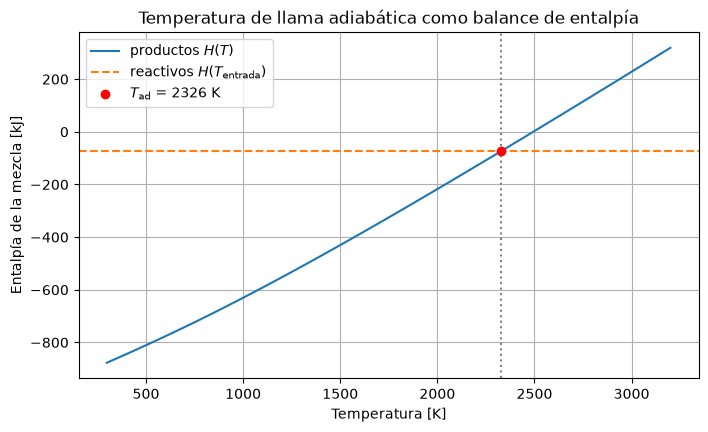

In [5]:
Tgrid = np.linspace(298.15, 3200, 80)
with ThermochemicalCalculator() as calc:
    H_prod = np.array([mixture_enthalpy(calc, products, T) for T in Tgrid]) / 1000.0
    H_react = mixture_enthalpy(calc, reactants, 298.15) / 1000.0

fig, ax = plt.subplots()
ax.plot(Tgrid, H_prod, label="productos $H(T)$")
ax.axhline(H_react, color="C1", ls="--", label=r"reactivos $H(T_\mathrm{entrada})$")
ax.axvline(Tad, color="0.5", ls=":")
ax.scatter([Tad], [H_react], color="red", zorder=5, label=rf"$T_\mathrm{{ad}}$ = {Tad:.0f} K")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("Entalpía de la mezcla [kJ]")
ax.set_title("Temperatura de llama adiabática como balance de entalpía")
ax.legend()
plt.show()

## 4. Efecto de la relación de equivalencia

La **relación de equivalencia** $\phi$ es la relación combustible/aire real
dividida por la estequiométrica. Mezclas pobres ($\phi<1$) contienen exceso de
aire que absorbe calor sin liberar más energía, reduciendo $T_\mathrm{ad}$.
Asumiendo combustión completa, para $\phi \le 1$ los productos son CO₂, H₂O, el
O₂ sobrante y todo el N₂.

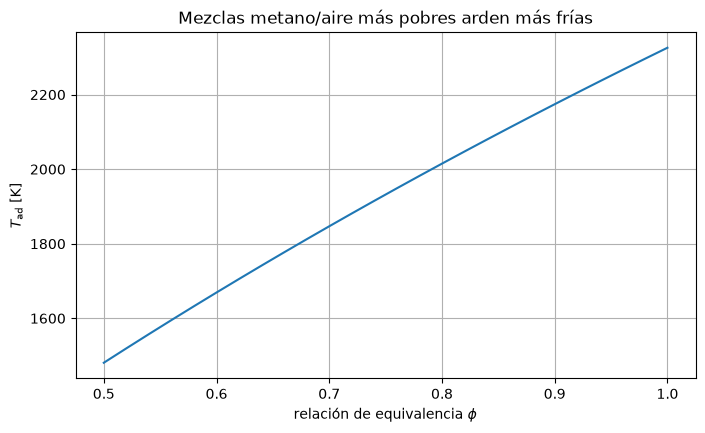

estequiométrica (phi=1,0): 2326 K
pobre           (phi=0,5): 1481 K


In [6]:
def flame_T_phi(calc, phi, T_in=298.15):
    """Temperatura de llama adiabática CH4/aire a relación de equivalencia phi (<=1)."""
    o2 = 2.0 / phi
    n2 = o2 * 3.76
    reac = {"CH4": 1.0, "O2": o2, "N2": n2}
    prod = {"CO2": 1.0, "H2O": 2.0, "O2": o2 - 2.0, "N2": n2}
    prod = {k: v for k, v in prod.items() if v > 0}
    return adiabatic_flame_T(calc, reac, prod, T_in)

phis = np.linspace(0.5, 1.0, 26)
with ThermochemicalCalculator() as calc:
    Tad_phi = [flame_T_phi(calc, p) for p in phis]

fig, ax = plt.subplots()
ax.plot(phis, Tad_phi)
ax.set_xlabel(r"relación de equivalencia $\phi$")
ax.set_ylabel(r"$T_\mathrm{ad}$ [K]")
ax.set_title("Mezclas metano/aire más pobres arden más frías")
plt.show()
print(f"estequiométrica (phi=1,0): {Tad_phi[-1]:.0f} K")
print(f"pobre           (phi=0,5): {Tad_phi[0]:.0f} K")

## 5. Efecto del precalentamiento de reactivos

Precalentar el aire de entrada (recuperación de calor, común en turbinas de gas)
eleva la entalpía de los reactivos y, por lo tanto, $T_\mathrm{ad}$. Aquí
barremos la temperatura de entrada para la mezcla estequiométrica.

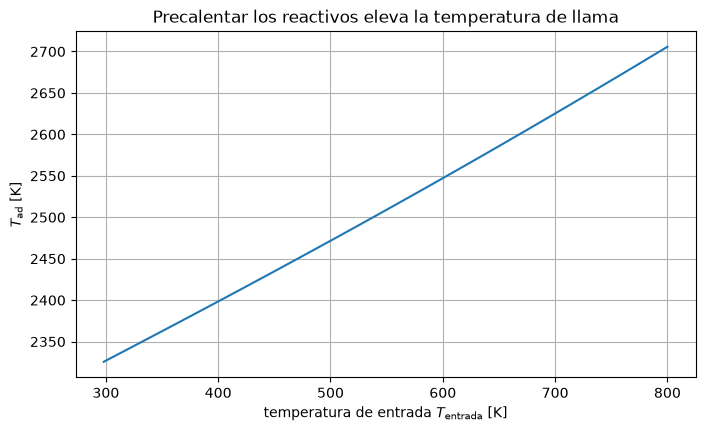

In [7]:
T_in_grid = np.linspace(298.15, 800, 25)
with ThermochemicalCalculator() as calc:
    Tad_preheat = [adiabatic_flame_T(calc, reactants, products, T_in=Ti)
                   for Ti in T_in_grid]

fig, ax = plt.subplots()
ax.plot(T_in_grid, Tad_preheat)
ax.set_xlabel(r"temperatura de entrada $T_\mathrm{entrada}$ [K]")
ax.set_ylabel(r"$T_\mathrm{ad}$ [K]")
ax.set_title("Precalentar los reactivos eleva la temperatura de llama")
plt.show()

## 6. Comparando combustibles

Temperaturas de llama estequiométricas en aire (entrada a 298,15 K) para cuatro
combustibles. Todos usan su propia demanda de oxígeno; el hidrógeno y los
hidrocarburos se agrupan una vez diluidos por el nitrógeno atmosférico.

             T_ad [K]
combustible          
H2          2,519.601
CH4         2,325.684
C3H8        2,391.472
C2H5OH      2,351.714


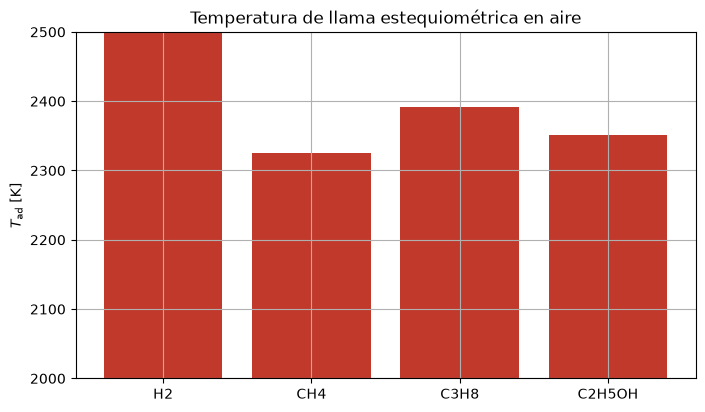

In [8]:
FUEL_STOICH = {
    "H2":     ({"O2": 0.5}, {"CO2": 0, "H2O": 1}),
    "CH4":    ({"O2": 2.0}, {"CO2": 1, "H2O": 2}),
    "C3H8":   ({"O2": 5.0}, {"CO2": 3, "H2O": 4}),
    "C2H5OH": ({"O2": 3.0}, {"CO2": 2, "H2O": 3}),
}

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (o2d, prod) in FUEL_STOICH.items():
        nO2 = o2d["O2"]
        nN2 = nO2 * 3.76
        reac = {fuel: 1.0, "O2": nO2, "N2": nN2}
        products_f = {k: v for k, v in {**prod, "N2": nN2}.items() if v > 0}
        Tad_f = adiabatic_flame_T(calc, reac, products_f, T_in=298.15)
        rows.append({"combustible": fuel, "T_ad [K]": Tad_f})

fuel_df = pd.DataFrame(rows).set_index("combustible")
print(fuel_df.to_string())

fig, ax = plt.subplots()
ax.bar(fuel_df.index, fuel_df["T_ad [K]"], color="#c0392b")
ax.set_ylabel(r"$T_\mathrm{ad}$ [K]")
ax.set_ylim(2000, 2500)
ax.set_title("Temperatura de llama estequiométrica en aire")
plt.show()

## Advertencia: disociación

Este modelo asume **combustión completa** a CO₂ y H₂O. Las llamas reales por
encima de ~2000 K disocian parcialmente los productos (en CO, OH, H, O, NO,
...), lo que absorbe energía y limita la temperatura de llama real **100–300 K
por debajo** de estas estimaciones. El cuaderno 08 cuantifica la disociación
mediante equilibrio químico.

**A continuación:** el cuaderno 07 aplica estas herramientas de combustión para
comparar biocombustibles.